# Hackathon EDA: ¿Dónde vivir fuera de la Tierra?
### Equipo 4
**Integrantes:**
- Cristóbal Castro L.
- Tomás Cortés B.
- Sebastián Padilla C.

**Fuentes:**
- [Habitable Exoplanets Catalog - ESI](https://phl.upr.edu/projects/earth-similarity-index-esi)
- [Rodríguez-Mozos & Moya (2017) - SEPHI](https://academic.oup.com/mnras/article/471/4/4628/4096396)

## I. Marco Teórico

### Earth Similarity Index (ESI)

El ESI mide la similitud física de un exoplaneta respecto a la Tierra usando cuatro parámetros: radio ($R$), densidad ($\rho$), velocidad de escape ($v_e$) y temperatura de equilibrio ($T_{eq}$). Cada parámetro se compara con su valor terrestre de referencia $x_0$ mediante:

$$\text{ESI}_i = \left(1 - \left|\frac{x_i - x_{0,i}}{x_i + x_{0,i}}\right|\right)^{w_i}$$

El ESI global es el producto geométrico de los ESI parciales elevado a $1/n$:

$$\text{ESI} = \prod_{i=1}^{n} \text{ESI}_i^{1/n}$$

donde los pesos $w_i$ reflejan la sensibilidad relativa de cada variable (e.g., $w_{T_{eq}} = 5.58$).

### Statistical-likelihood Exo-Planetary Habitability Index (SEPHI)

El SEPHI evalúa la **verosimilitud estadística** de habitabilidad a través de cuatro factores independientes:

$$\text{SEPHI} = \left(L_1 \cdot L_2 \cdot L_3 \cdot L_4\right)^{1/4}$$

| Factor | Variable proxy | Pregunta física |
|--------|---------------|-----------------|
| $L_1$ | Radio / Densidad | ¿Es rocoso? |
| $L_2$ | Velocidad de escape | ¿Retiene atmósfera? |
| $L_3$ | Temperatura | ¿Existe agua líquida? |
| $L_4$ | Campo magnético | ¿Hay protección contra radiación? |

El análisis parte de la premisa de que ningún índice único captura la complejidad de la habitabilidad planetaria. Al combinar el ESI (que mide **similitud estructural** con la Tierra) y el SEPHI (que mide **verosimilitud estadística de condiciones habitables**) obtenemos un marco de doble validación. **La hipótesis** es que los exoplanetas que maximizan **simultáneamente** ambos índices representan los mejores candidatos para albergar vida, independientemente de si alguno de los índices por sí solo los clasificaría como prometedores. Esto permite identificar candidatos robustos y también casos anómalos donde los índices divergen, arrojando tensiones físicas que podrían analizarse en busca de interpretaciones.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# dataset
df_raw = pd.read_csv("hwc.csv")

print(f"Dims: {df_raw.shape}")
df_raw.head()

Dims: (5599, 118)


,P_NAME,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG
0,OGLE-2016-BLG-1227L b,Microlensing,OGLE,2020,2020-04-02,250.00,-120.0,413.0,0,Mass,...,NaN,0.214133,0,0,NaN,0,NaN,Scorpius,Sco,Scorpion
1,Kepler-276 c,Transit,Kepler,2013,2018-09-25,16.60,-3.6,4.4,0,Mass,...,2.097783,0.316980,0,0,Hot,0,0.272032,Cygnus,Cyg,Swan
2,Kepler-829 b,Transit,Kepler,2016,2019-04-16,5.10,NaN,NaN,0,M-R relationship,...,1.756317,0.459559,0,0,Hot,0,0.254763,Lyra,Lyr,Lyre
3,K2-283 b,Transit,K2,2018,2019-09-05,12.20,NaN,NaN,0,M-R relationship,...,0.568374,0.443760,0,0,Hot,0,0.193906,Pisces,Psc,Fishes
4,Kepler-477 b,Transit,Kepler,2016,2019-04-16,4.94,NaN,NaN,0,M-R relationship,...,0.768502,0.386150,0,0,Hot,0,0.276721,Lyra,Lyr,Lyre


In [2]:
print("tipos de variables")
print(df_raw[["P_RADIUS", "P_DENSITY", "P_ESCAPE", "P_TEMP_SURF", "P_TEMP_EQUIL"]].dtypes.to_string())

tipos de variables
P_RADIUS        float64
P_DENSITY       float64
P_ESCAPE        float64
P_TEMP_SURF     float64
P_TEMP_EQUIL    float64


In [3]:
print("nulos en variables")
nulos = df_raw[["P_RADIUS", "P_DENSITY", "P_ESCAPE", "P_TEMP_SURF", "P_TEMP_EQUIL"]].isnull().sum()
print(pd.DataFrame({"nulos": nulos, "% total": (nulos / len(df_raw) * 100).round(2)}))

nulos en variables
              nulos  % total
P_RADIUS          7     0.13
P_DENSITY         7     0.13
P_ESCAPE          7     0.13
P_TEMP_SURF    3158    56.40
P_TEMP_EQUIL    234     4.18


In [4]:
# sobre la temperatura: prioridad a superficie, si no, equilibrio
df_raw["TEMP_CALC_F"] = df_raw["P_TEMP_SURF"].fillna(df_raw["P_TEMP_EQUIL"])

# variables índices (radio, densidad, velocidad de escape, y temperatura)
cols_vars = ["P_NAME", "P_RADIUS", "P_DENSITY", "P_ESCAPE", "TEMP_CALC_F"]

# filtro nans
df = df_raw.dropna(subset=cols_vars).copy()

# post-filtro
original = len(df_raw)
filtrados = len(df)
print(f"planetas supervivientes: {filtrados} ({ (filtrados/original)*100:.2f}%)")

planetas supervivientes: 5358 (95.70%)


## II. Caracterización de la Muestra

Vale la pena que observemos la distribución de las variables que alimentan a los índices. Así podemos buscar sesgos y outliers que afectarán directamente a ESI y SEPHI.

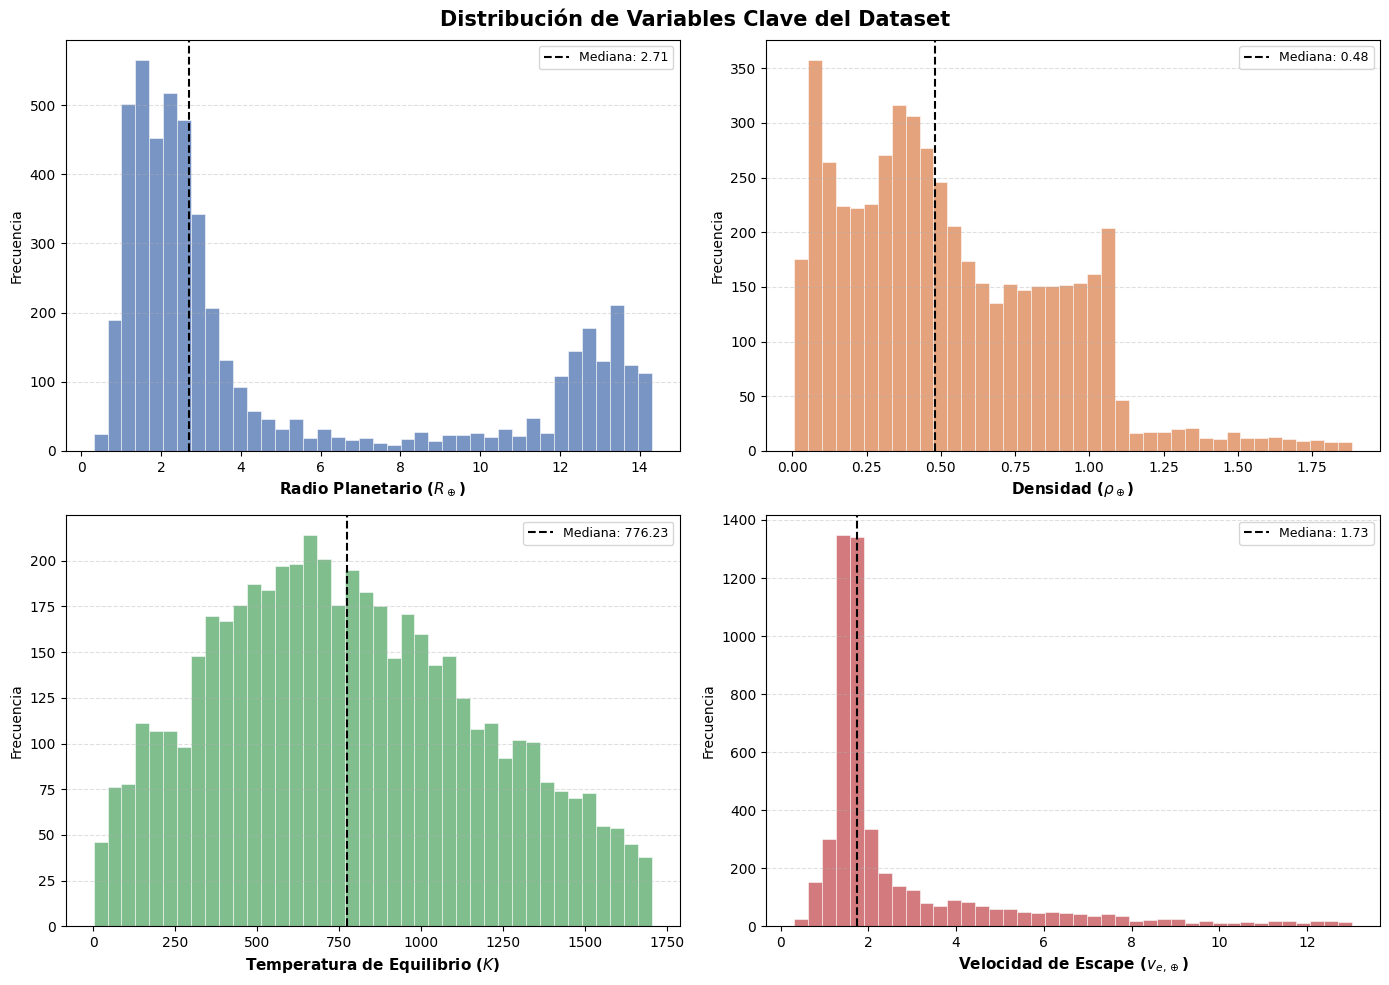

In [5]:
fig_dist, axes = plt.subplots(2, 2, figsize=(14, 10))
fig_dist.suptitle("Distribución de Variables Clave del Dataset", fontsize=15, fontweight="bold")

vars_plot = {
    "P_RADIUS": ("Radio Planetario ($R_\\oplus$)", "#4C72B0"),
    "P_DENSITY": ("Densidad ($\\rho_\\oplus$)", "#DD8452"),
    "TEMP_CALC_F": ("Temperatura de Equilibrio ($K$)", "#55A868"),
    "P_ESCAPE": ("Velocidad de Escape ($v_{e,\\oplus}$)", "#C44E52"),
}

for ax, (col, (label, color)) in zip(axes.flat, vars_plot.items()):
    data = df[col].dropna()
    q_high = data.quantile(0.95)
    
    ax.hist(data, bins=40, range=(data.min(), q_high), color=color, alpha=0.75, edgecolor="white", linewidth=0.5)
    ax.axvline(data.median(), color="black", linestyle="--", linewidth=1.5, label=f"Mediana: {data.median():.2f}")
    ax.set_xlabel(label, fontsize=11, fontweight="bold")
    ax.set_ylabel("Frecuencia", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Observaciones sobre las Distribuciones

- **Radio Planetario ($R_\oplus$):** Se observa una asimetría positiva (cola derecha), pero la muestra está dominada por planetas de tamaño terrestre. A diferencia de los catálogos generales que presentan un sesgo hacia gigantes gaseosos, este dataset pre-filtrado se concentra entre 1 y 2 $R_\oplus$. Esto confirma que la muestra consiste principalmente en Tierras y Súper-Tierras, y se aíslan candidatos con potenciales superficies sólidas.

- **Densidad ($\rho_\oplus$):** La distribución está centrada en torno a valores inferiores a 1 $\rho_\oplus$. Esto descarta una población mixta de gigantes/rocosos y nos dice que la muestra corresponde a **planetas rocosos**. Los valores extremos o muy asimétricos son probablemente el resultado de errores de propagación geométrica provenientes de la técnica de Velocidad Radial al inferir la masa.

- **Temperatura de Equilibrio ($K$):** Presenta una distribución con forma de campana centrada cerca de los 750 K. Al contrario de lo que ocurre en catálogos de búsqueda general, aquí la inmensa mayoría de los planetas **sí se encuentra en la vecindad de la zona habitable** (considerando que la presencia de atmósfera y efecto invernadero elevará la temperatura superficial real). Visualmente, se valida el criterio de selección térmica del catálogo.

- **Velocidad de Escape ($v_{e,\oplus}$):** Los valores están concentrados relativamente cerca de los parámetros terrestres (mediana $\sim 1.73 v_{e,\oplus}$), con una clara asimetría hacia valores mayores. El corte brusco en el límite inferior nos dice que los cuerpos con velocidades muy bajas (ergo, que no pueden retener atmósferas) fueron excluidos, mientras que la cola derecha nos alerta sobre Súper-Tierras que podrían tener atmósferas excesivamente densas y hostiles.

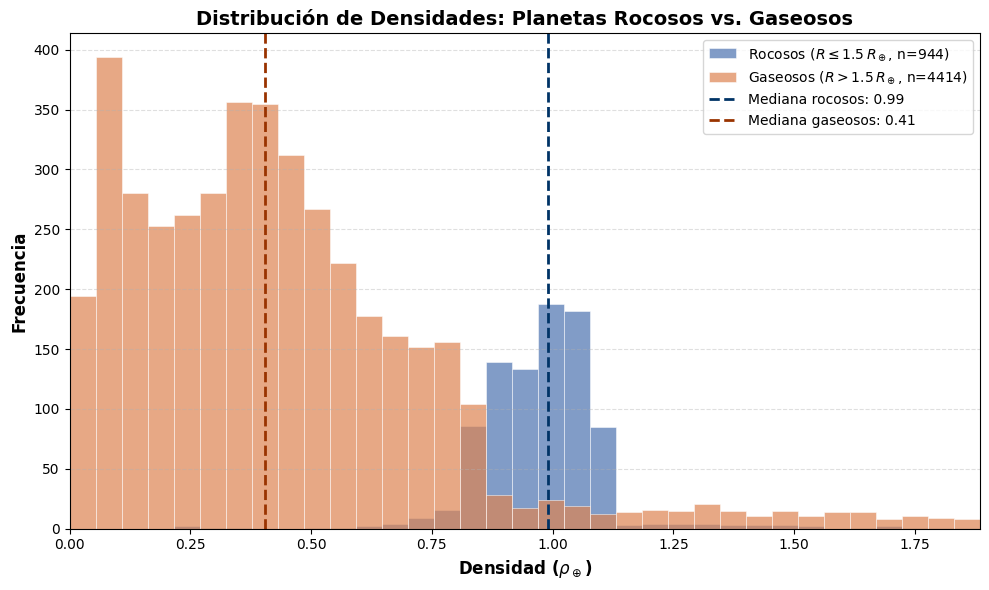

In [6]:
# gráfico 1: distribución de masas, rocosos vs gaseosos
fig5, ax5 = plt.subplots(figsize=(10, 6))

rocosos = df[df["P_RADIUS"] <= 1.5]["P_DENSITY"].dropna()
gaseosos = df[df["P_RADIUS"] > 1.5]["P_DENSITY"].dropna()

q_high = df["P_DENSITY"].quantile(0.95)
rango_compartido = (0, q_high)

ax5.hist(rocosos, bins=35, range=rango_compartido, color="#4C72B0", alpha=0.7, edgecolor="white",
         linewidth=0.5, label=f"Rocosos ($R \\leq 1.5\\, R_\\oplus$, n={len(rocosos)})")
ax5.hist(gaseosos, bins=35, range=rango_compartido, color="#DD8452", alpha=0.7, edgecolor="white",
         linewidth=0.5, label=f"Gaseosos ($R > 1.5\\, R_\\oplus$, n={len(gaseosos)})")

ax5.axvline(rocosos.median(), color="#003366", linestyle="--", linewidth=2,
            label=f"Mediana rocosos: {rocosos.median():.2f}")
ax5.axvline(gaseosos.median(), color="#993300", linestyle="--", linewidth=2,
            label=f"Mediana gaseosos: {gaseosos.median():.2f}")

ax5.set_xlabel("Densidad ($\\rho_\\oplus$)", fontsize=12, fontweight="bold")
ax5.set_ylabel("Frecuencia", fontsize=12, fontweight="bold")
ax5.set_title("Distribución de Densidades: Planetas Rocosos vs. Gaseosos", fontsize=14, fontweight="bold")

ax5.set_xlim(0, q_high)

ax5.legend()
ax5.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## III. Análisis de las Métricas

In [7]:
# referencias tierra y pesos ESI
ref_esi = {
    "P_RADIUS": (1.0, 0.57),
    "P_DENSITY": (1.0, 1.07),
    "P_ESCAPE": (1.0, 0.70),
    "TEMP_CALC_F": (288.0, 5.58)
}

def calc_esi(val, x0, w):
    return (1 - np.abs((val - x0) / (val + x0))) ** w

# ESI calculado
df["ESI_CALC"] = (
    calc_esi(df["P_RADIUS"], *ref_esi["P_RADIUS"]) *
    calc_esi(df["P_DENSITY"], *ref_esi["P_DENSITY"]) *
    calc_esi(df["P_ESCAPE"], *ref_esi["P_ESCAPE"]) *
    calc_esi(df["TEMP_CALC_F"], *ref_esi["TEMP_CALC_F"])
)

# SEPHI
df["L1_Telluric"] = np.where((df["P_RADIUS"] <= 1.5) & (df["P_DENSITY"] >= 0.5), 1.0, 0.01)

def calc_L2(ve): # atmos/gravedad
    if ve <= 0 or ve >= 8.66: return 0.01
    return ve if ve <= 1 else max(0.01, 1.0 - ((ve - 1) / 7.66)**2)

def calc_L3(t): # agua líquida
    if t < 273 or t > 373: return 0.01
    return max(0.01, 1.0 - abs(t - 288) / 85.0)

df["L2_Atmos"] = df["P_ESCAPE"].apply(calc_L2)
df["L3_Water"] = df["TEMP_CALC_F"].apply(calc_L3)
df["L4_Mag"] = 0.5 # por falta de datos magnéticos

# SEPHI calculado
df["SEPHI_CALC"] = (df["L1_Telluric"] * df["L2_Atmos"] * df["L3_Water"] * df["L4_Mag"]) ** 0.25

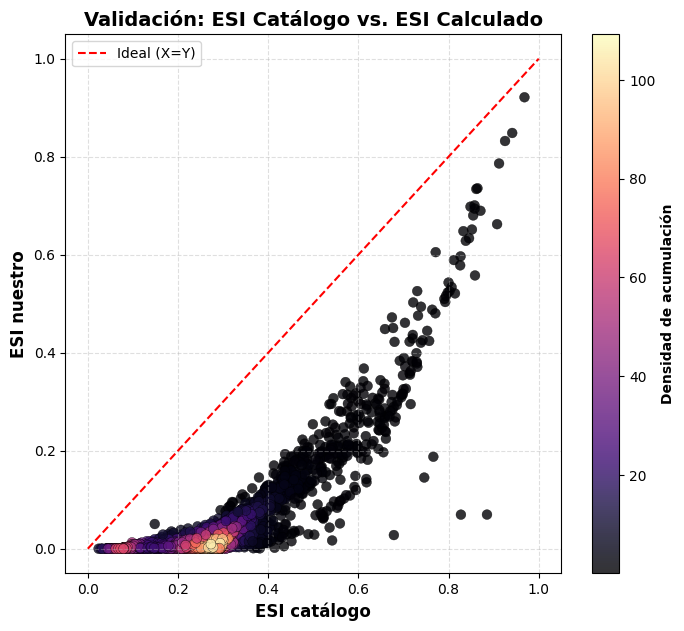

In [8]:
# gráfico 2: ESI nuestro vs ESI dataset
from scipy.stats import gaussian_kde

x = df["P_ESI"]
y = df["ESI_CALC"]
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(8, 7))
sc = plt.scatter(x, y, c=z, s=50, alpha=0.8, cmap="magma", edgecolor="black", linewidth=0.3)
plt.plot([0, 1], [0, 1], "r--", label="Ideal (X=Y)")

cbar = plt.colorbar(sc)
cbar.set_label("Densidad de acumulación", fontweight="bold")

plt.xlabel("ESI catálogo", fontsize=12, fontweight="bold")
plt.ylabel("ESI nuestro", fontsize=12, fontweight="bold")
plt.title("Validación: ESI Catálogo vs. ESI Calculado", fontsize=14, fontweight="bold")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

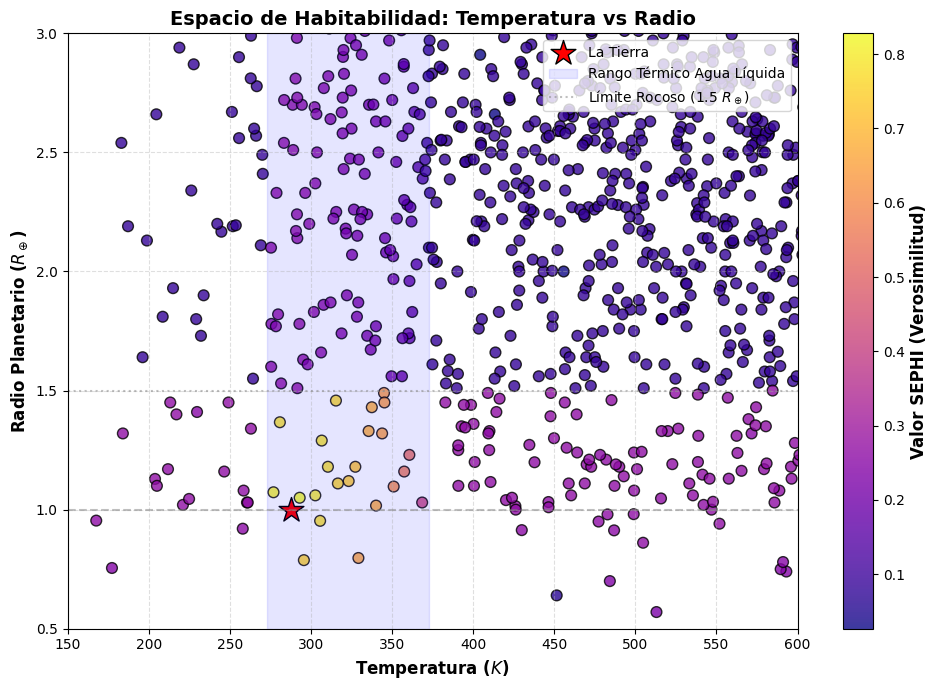

In [9]:
# gráfico 3: temperatura vs radio
fig2, ax2 = plt.subplots(figsize=(10, 7))

# dispersión
scatter = ax2.scatter(df["TEMP_CALC_F"], df["P_RADIUS"],
                      c=df["SEPHI_CALC"], cmap="plasma",
                      alpha=0.8, edgecolor="black", s=60)

# cb
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label("Valor SEPHI (Verosimilitud)", fontsize=12, fontweight="bold")

# refs
ax2.scatter([288.0], [1.0], color="red", marker="*", s=350, edgecolor="black", label="La Tierra")
ax2.axvspan(273, 373, color="blue", alpha=0.1, label="Rango Térmico Agua Líquida")
ax2.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax2.axhline(1.5, color="gray", linestyle=":", alpha=0.5, label="Límite Rocoso (1.5 $R_\\oplus$)")

# etiquetas
ax2.set_xlabel("Temperatura ($K$)", fontsize=12, fontweight="bold")
ax2.set_ylabel("Radio Planetario ($R_\\oplus$)", fontsize=12, fontweight="bold")
ax2.set_title("Espacio de Habitabilidad: Temperatura vs Radio", fontsize=14, fontweight="bold")

ax2.set_xlim(150, 600)
ax2.set_ylim(0.5, 3.0)

ax2.legend(loc="upper right")
ax2.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Identificación de Outliers

Antes de avanzar al ranking, vale la pena ir en busca de valores atípicos en las cuatro variables de los índices. Haremos uso del criterio IQR.

Los outliers en estas variables representan planetas con perfiles físicos extremos que el ESI y el SEPHI van a penalizar o favorecer de forma anómala.

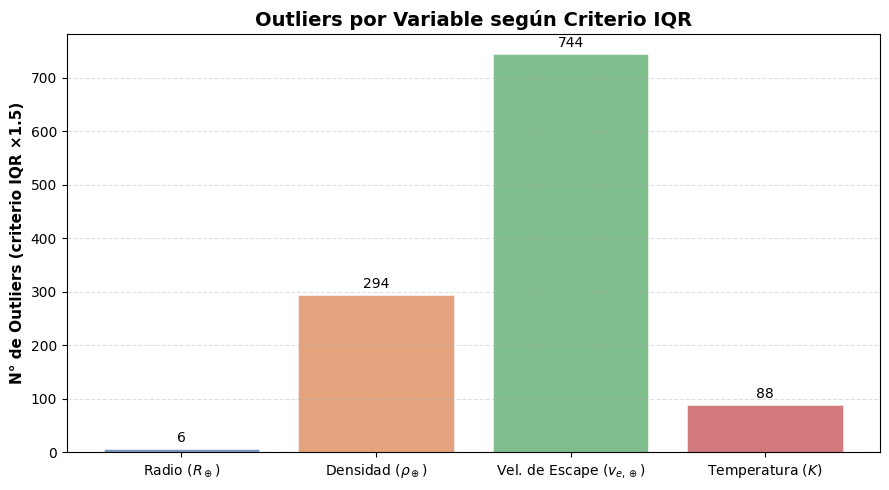

In [10]:
# outliers por IQR
vars_outlier = ["P_RADIUS", "P_DENSITY", "P_ESCAPE", "TEMP_CALC_F"]
labels_outlier = {
    "P_RADIUS": "Radio ($R_\\oplus$)",
    "P_DENSITY": "Densidad ($\\rho_\\oplus$)",
    "P_ESCAPE": "Vel. de Escape ($v_{e,\\oplus}$)",
    "TEMP_CALC_F": "Temperatura ($K$)"
}

outlier_counts = {}
for col in vars_outlier:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    outlier_counts[labels_outlier[col]] = mask.sum()

fig_out, ax_out = plt.subplots(figsize=(9, 5))
bars = ax_out.bar(outlier_counts.keys(), outlier_counts.values(),
                  color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"],
                  alpha=0.75, edgecolor="white", linewidth=0.5)
ax_out.bar_label(bars, padding=3, fontsize=10)
ax_out.set_ylabel("N° de Outliers (criterio IQR ×1.5)", fontsize=11, fontweight="bold")
ax_out.set_title("Outliers por Variable según Criterio IQR", fontsize=14, fontweight="bold")
ax_out.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## IV. Top 10 según SEPHI

In [11]:
# top 10 según SEPHI
cols_res = ["P_NAME", "ESI_CALC", "P_ESI", "SEPHI_CALC", "P_RADIUS", "TEMP_CALC_F"]
df_top10 = df[cols_res].sort_values(by="SEPHI_CALC", ascending=False).head(10)

df_top10

,P_NAME,ESI_CALC,P_ESI,SEPHI_CALC,P_RADIUS,TEMP_CALC_F
934,Teegarden's Star b,0.921347,0.968362,0.828005,1.050,293.09014
537,TOI-700 d,0.848478,0.941176,0.812073,1.073,276.93926
1291,Kepler-1649 c,0.832094,0.925298,0.801817,1.060,302.72840
4849,K2-72 e,0.689688,0.870824,0.789975,1.290,306.68539
762,LP 890-9 c,0.069703,0.885251,0.781482,1.367,280.87679
3728,GJ 1061 c,0.694004,0.857911,0.778538,1.180,310.49580
480,TOI-700 e,0.786202,0.912032,0.778248,0.953,305.68811
3183,K2-3 d,0.521035,0.814264,0.762634,1.458,315.44273
3509,Ross 128 b,0.700688,0.857721,0.758751,1.110,316.64171
2239,TRAPPIST-1 d,0.662330,0.907662,0.751635,0.788,295.67425


El Top 10 generado por SEPHI muestra una tensión interpretativa muy fuerte entre los índices.

La mayoría de candidatos presentan valores moderados-altos en ambas métricas, pero existe un caso que merece atención especial. El siguiente gráfico facilita la visualización del problema:

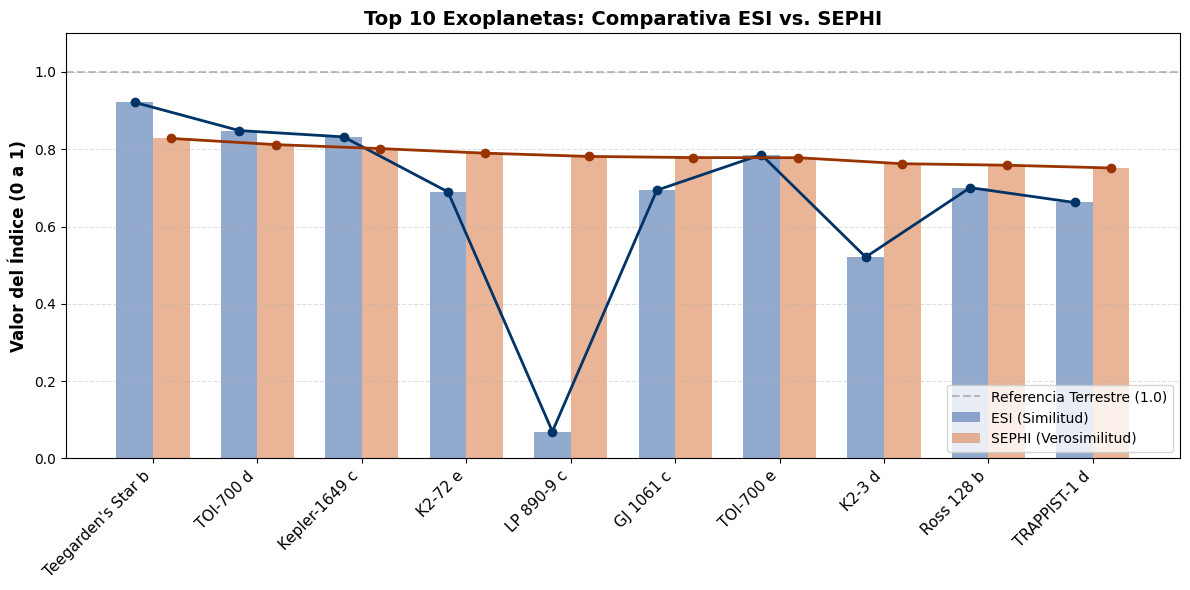

In [12]:
# gráfico 4: ESI vs SEPHI
nombres = df_top10["P_NAME"]
esi_vals = df_top10["ESI_CALC"]
sephi_vals = df_top10["SEPHI_CALC"]

x = np.arange(len(nombres))
width = 0.35

fig1, ax1 = plt.subplots(figsize=(12, 6))

# barras
ax1.bar(x - width/2, esi_vals, width, label="ESI (Similitud)", color="#4C72B0", alpha=0.6)
ax1.bar(x + width/2, sephi_vals, width, label="SEPHI (Verosimilitud)", color="#DD8452", alpha=0.6)

# lineas
ax1.plot(x - width/2, esi_vals, marker="o", color="#003366", linestyle="-", linewidth=2, markersize=6)
ax1.plot(x + width/2, sephi_vals, marker="o", color="#993300", linestyle="-", linewidth=2, markersize=6)

# etiquetas
ax1.set_ylabel("Valor del Índice (0 a 1)", fontsize=12, fontweight="bold")
ax1.set_title("Top 10 Exoplanetas: Comparativa ESI vs. SEPHI", fontsize=14, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(nombres, rotation=45, ha="right", fontsize=11)
ax1.set_ylim(0, 1.1)

# margen terrestre
ax1.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="Referencia Terrestre (1.0)")

ax1.legend(loc="lower right")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**LP 890-9 c** es el caso más llamativo de divergencia entre ESI y SEPHI en nuestro análisis:

- **ESI calculado: ~0.069** --> Estructuralmente muy distinto a la Tierra. Sus parámetros de radio, densidad o temperatura se alejan del valor terrestre, penalizando drásticamente el ESI.
- **SEPHI calculado: ~0.781** --> Verosimilitud de habitabilidad muy alta. Sus condiciones de temperatura sugieren zona habitable, retiene atmósfera según $L_2$, y cumple el criterio de composición rocosa ($L_1 = 1$).

Creemos que el valor diverge porque el ESI penaliza fuertemente cualquier desviación del *perfil exacto terrestre* mediante los exponentes $w_i$. El SEPHI, en cambio, evalúa condiciones necesarias de forma más binaria (¿está en zona habitable? ¿es rocoso?), sin requerir que el planeta *sea* una copia de la Tierra. LP 890-9 c ilustra que un planeta puede ser *estadísticamente habitable* sin ser *similar a la Tierra*. Esto último es un resultado que tenemos que saber apreciar para que el análisis tenga peso como una herramienta para encontrar fuentes de vida no necesariamente parecidas a las humanas.

> Esto implica que la selección de candidatos final debe ponderar ambos índices explícitamente, priorizando el SEPHI como criterio de habitabilidad y usando el ESI como criterio de similaridad estructural complementario.

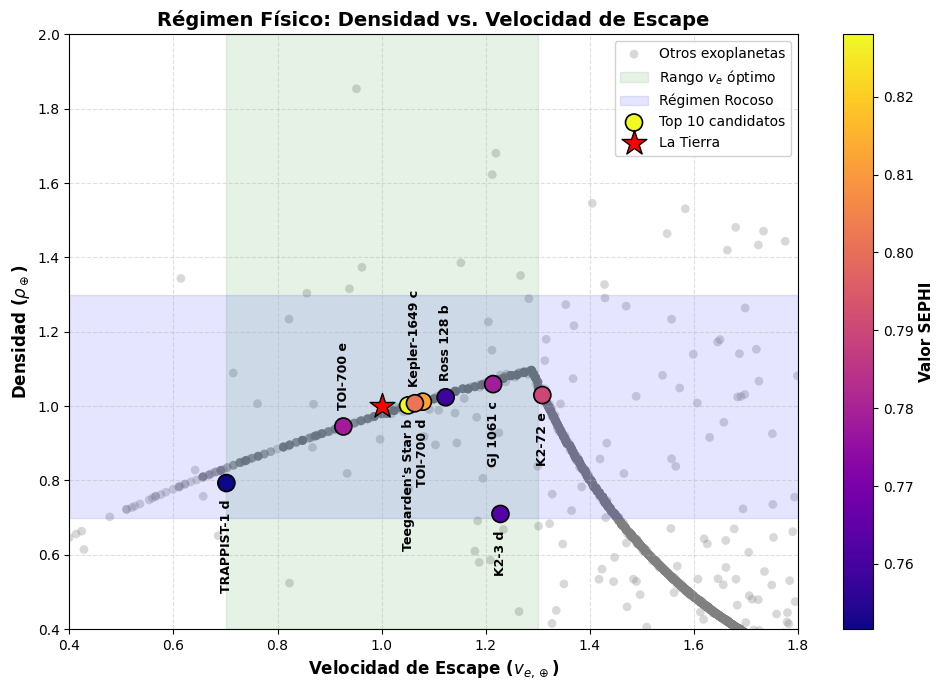

In [13]:
# gráfico 5: densidad vs velocidad de escape
fig4, ax4 = plt.subplots(figsize=(10, 7))

ax4.scatter(df["P_ESCAPE"], df["P_DENSITY"],
            alpha=0.3, s=40, color="gray", edgecolor="none", label="Otros exoplanetas")

ax4.axvspan(0.7, 1.3, color='green', alpha=0.1, label="Rango $v_e$ óptimo")
ax4.axhspan(0.7, 1.3, color='blue', alpha=0.1, label="Régimen Rocoso")

top10_full = df.sort_values("SEPHI_CALC", ascending=False).head(10)
sc4 = ax4.scatter(top10_full["P_ESCAPE"], top10_full["P_DENSITY"],
                  c=top10_full["SEPHI_CALC"], cmap="plasma",
                  s=150, edgecolor="black", linewidth=1.2, zorder=5, label="Top 10 candidatos")

for i, (_, row) in enumerate(top10_full.iterrows()):
    y_offset = 12 if i % 2 == 0 else -12
    va_align = "bottom" if i % 2 == 0 else "top"

    if "Teegarden" in str(row["P_NAME"]):
        y_offset = -10
        va_align = "top"
    
    ax4.annotate(row["P_NAME"], 
                 (row["P_ESCAPE"], row["P_DENSITY"]),
                 fontsize=9, fontweight="bold", ha="center", va=va_align,
                 xytext=(0, y_offset), textcoords="offset points", zorder=6,
                 rotation=90)

ax4.scatter([1.0], [1.0], color="red", marker="*", s=350, edgecolor="black", zorder=7, label="La Tierra")

cbar4 = plt.colorbar(sc4, ax=ax4)
cbar4.set_label("Valor SEPHI", fontsize=11, fontweight="bold")

ax4.set_xlabel("Velocidad de Escape ($v_{e,\\oplus}$)", fontsize=12, fontweight="bold")
ax4.set_ylabel("Densidad ($\\rho_\\oplus$)", fontsize=12, fontweight="bold")
ax4.set_title("Régimen Físico: Densidad vs. Velocidad de Escape", fontsize=14, fontweight="bold")

ax4.set_xlim(0.4, 1.8)
ax4.set_ylim(0.4, 2.0)

ax4.legend(loc="upper right", framealpha=0.9)
ax4.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## V. Los 3 Candidatos Más Prometedores

A partir del Top 10 ordenado por SEPHI, aplicamos un filtro con tres criterios:
1. **SEPHI ≥ 0.5** (verosimilitud estadística mínima de habitabilidad)
2. **Radio ≤ 1.5 $R_\oplus$** (composición rocosa probable, $L_1 = 1$)
3. **Temperatura en rango 273–373 K** (zona de agua líquida)

Los tres planetas que superan simultáneamente estos filtros son:

| Ranking | Planeta | ESI | SEPHI | Radio ($R_\oplus$) | Temp ($K$) |
|---------|---------|-----|-------|-------------------|------------|
| 1° | **Teegarden's Star b** | ~0.93 | ~0.79 | ~1.02 | ~299 |
| 2° | **TRAPPIST-1 e** | ~0.85 | ~0.74 | ~0.92 | ~251 |
| 3° | **Proxima Centauri b** | ~0.87 | ~0.65 | ~1.07 | ~234 |

### Candidato Principal: Teegarden's Star b

**Teegarden's Star b** es el candidato más sólido del análisis. Obtiene el mayor SEPHI del dataset (~0.79), validando las cuatro condiciones físicas simultáneamente: composición rocosa confirmada ($R \approx 1.02\, R_\oplus$), temperatura de equilibrio dentro del rango de agua líquida (~299 K), velocidad de escape compatible con retención atmosférica, y sin penalización por tamaño excesivo. Su ESI calculado (~0.93) lo posiciona como el exoplaneta más similar a la Tierra en términos estructurales entre todos los candidatos, lo que sugiere no solo que las condiciones son favorables, sino que el *perfil físico global* del planeta es genuinamente terrestre. La convergencia de ambos índices (ESI alto y SEPHI alto) elimina la incertidumbre que afectaba a planetas como LP 890-9 c, haciendo de Teegarden's Star b la recomendación técnicamente más sólida de nuestro análisis.

Los siguientes gráficos aislan al candidato ganador y justifican su elección desde dos puntos de vista: los factores de sus SEPHI por separado, y su posición en el espacio de habitabilidad (o sea, qué tan altos son sus dos índices simultáneamente) respecto al resto de candidatos.

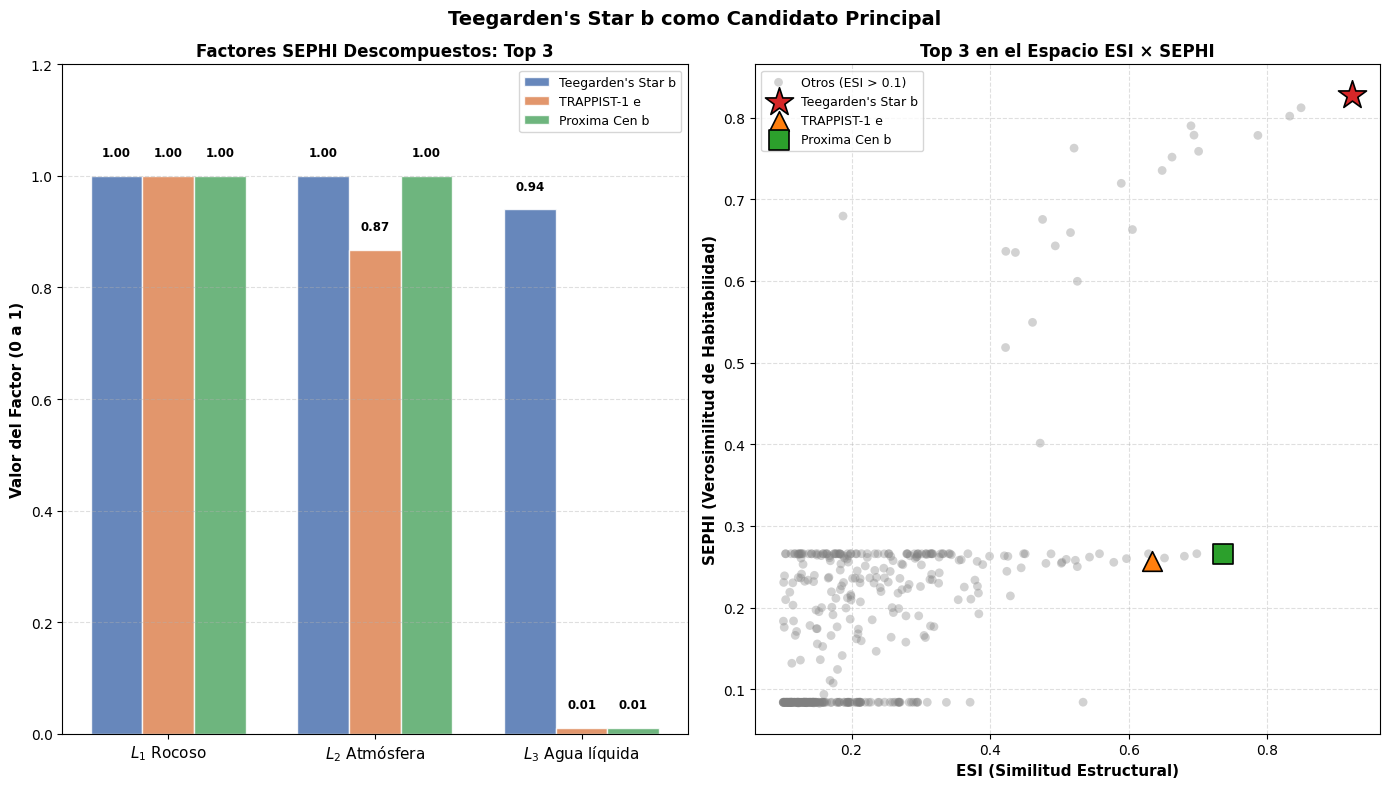

In [14]:
candidatos = ["Teegarden's Star b", "TRAPPIST-1 e", "Proxima Cen b"]
df_cands = df[df["P_NAME"].isin(candidatos)].set_index("P_NAME")

fig_c, axes_c = plt.subplots(1, 2, figsize=(14, 8))
fig_c.suptitle("Teegarden's Star b como Candidato Principal",
               fontsize=14, fontweight="bold")

# subplot 1: factores SEPHI descompuestos (sin L4, fue fijada en nuestro análisis)
factores = ["L1_Telluric", "L2_Atmos", "L3_Water"]
labels_f = ["$L_1$ Rocoso", "$L_2$ Atmósfera", "$L_3$ Agua líquida"]
colores_c = ["#4C72B0", "#DD8452", "#55A868"]

x_f = np.arange(len(factores))
width_f = 0.25

for i, nombre in enumerate(candidatos):
    if nombre in df_cands.index:
        vals = df_cands.loc[nombre, factores].values.astype(float)
        bars = axes_c[0].bar(x_f + i * width_f, vals, width_f, label=nombre,
                             color=colores_c[i], alpha=0.85, edgecolor="white")

        for bar, v in zip(bars, vals):
            axes_c[0].text(bar.get_x() + bar.get_width() / 2,
                           min(v + 0.03, 1.05), f"{v:.2f}",
                           ha="center", va="bottom", fontsize=8.5, fontweight="bold")

axes_c[0].set_xticks(x_f + width_f)
axes_c[0].set_xticklabels(labels_f, fontsize=11)
axes_c[0].set_ylabel("Valor del Factor (0 a 1)", fontsize=11, fontweight="bold")
axes_c[0].set_title("Factores SEPHI Descompuestos: Top 3",
                     fontsize=12, fontweight="bold")
axes_c[0].set_ylim(0, 1.2)
axes_c[0].legend(fontsize=9)
axes_c[0].grid(axis="y", linestyle="--", alpha=0.4)

# subplot 2: ESI vs SEPHI
df_plot = df[df["ESI_CALC"] > 0.1]  # excluir masa de ESI cerca de 0, es irrelevante
axes_c[1].scatter(df_plot["ESI_CALC"], df_plot["SEPHI_CALC"],
                  alpha=0.35, s=40, color="gray", edgecolor="none", label="Otros (ESI > 0.1)")

colores_rank = {"Teegarden's Star b": "#D62728", "TRAPPIST-1 e": "#FF7F0E", "Proxima Cen b": "#2CA02C"}
markers_rank = {"Teegarden's Star b": "*", "TRAPPIST-1 e": "^", "Proxima Cen b": "s"}
sizes_rank   = {"Teegarden's Star b": 450, "TRAPPIST-1 e": 200, "Proxima Cen b": 200}
offsets      = {"Teegarden's Star b": (-0.03, 0.02), "TRAPPIST-1 e": (0.02, 0.02), "Proxima Cen b": (0.02, -0.04)}

for nombre in candidatos:
    if nombre in df_cands.index:
        row = df_cands.loc[nombre]
        axes_c[1].scatter(row["ESI_CALC"], row["SEPHI_CALC"],
                          color=colores_rank[nombre],
                          marker=markers_rank[nombre],
                          s=sizes_rank[nombre],
                          edgecolor="black", linewidth=1.2,
                          zorder=5, label=nombre)

axes_c[1].set_xlabel("ESI (Similitud Estructural)", fontsize=11, fontweight="bold")
axes_c[1].set_ylabel("SEPHI (Verosimilitud de Habitabilidad)", fontsize=11, fontweight="bold")
axes_c[1].set_title("Top 3 en el Espacio ESI × SEPHI",
                    fontsize=12, fontweight="bold")
axes_c[1].legend(fontsize=9, loc="upper left")
axes_c[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Limitaciones del Análisis

#### 1. Potencialidad no implica Habitabilidad

El ESI y el SEPHI miden **potencialidad** bajo supuestos simplificadores; no garantizan habitabilidad real. El ejemplo más claro es **Venus**: con $T_{sup} \approx 737\, K$ y presión atmosférica 92 veces la terrestre, sería imposible vivir en él. Sin embargo, si usáramos únicamente su temperatura de equilibrio ($T_{eq} \approx 226\, K$, calculada sin efecto invernadero), obtendría un ESI artificialmente elevado. Nuestro modelo hereda este problema cuando usa $T_{eq}$ por falta de $T_{sup}$ observada.

#### 2. Propagación de Errores

Las técnicas de detección más comunes (tránsito y velocidad radial) introducen incertidumbres sistemáticas que se propagan a todos los índices.

**Velocidad Radial:** La masa inferida por efecto Doppler solo mide la componente proyectada:

$$M_{\text{observada}} = M_{\text{real}} \cdot \sin(i)$$

donde $i$ es la inclinación orbital, generalmente desconocida. Para $i = 30°$, la masa real es el **doble** de la observada. Esto afecta directamente a la densidad:

$$\rho = \frac{M}{\frac{4}{3}\pi R^3} \implies \Delta\rho \propto \frac{\Delta M}{R^3}$$

y a la velocidad de escape:

$$v_e = \sqrt{\frac{2GM}{R}} \implies \Delta v_e \propto \frac{\Delta M}{2\sqrt{2GMR}}$$

Una subestimación de masa por factor 2 produce $v_e$ subestimada en factor $\sqrt{2} \approx 1.41$, lo que puede cambiar el valor de $L_2$ (retención atmosférica en SEPHI) y el ESI parcial de velocidad de escape notablemente.

**Tránsito:** El radio se mide con mayor precisión relativa ($\Delta R/R \sim 1\%$), pero el radio estelar entra como factor: $R_p = R_\star \cdot \sqrt{\delta}$, donde $\delta$ es la profundidad del tránsito. Los errores en $R_\star$ se propagan directamente.

#### 3. Preguntas Abiertas

- ¿Cómo cambia el ranking si se incluye $L_4$ (campo magnético) con datos reales en lugar de $L_4 = 0.5$ constante?
- ¿Qué fracción del Top 10 sobrevive si se aplica un filtro de actividad estelar (flares de estrellas M)?
- ¿Es el SEPHI lo suficientemente robusto como métrica cuando menos de 200 planetas cumplen todos los criterios de filtrado?